<a href="https://colab.research.google.com/github/Kshejal20/Page-View-Time-Series-Visualizer/blob/main/Page_View_Time_Series_Visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

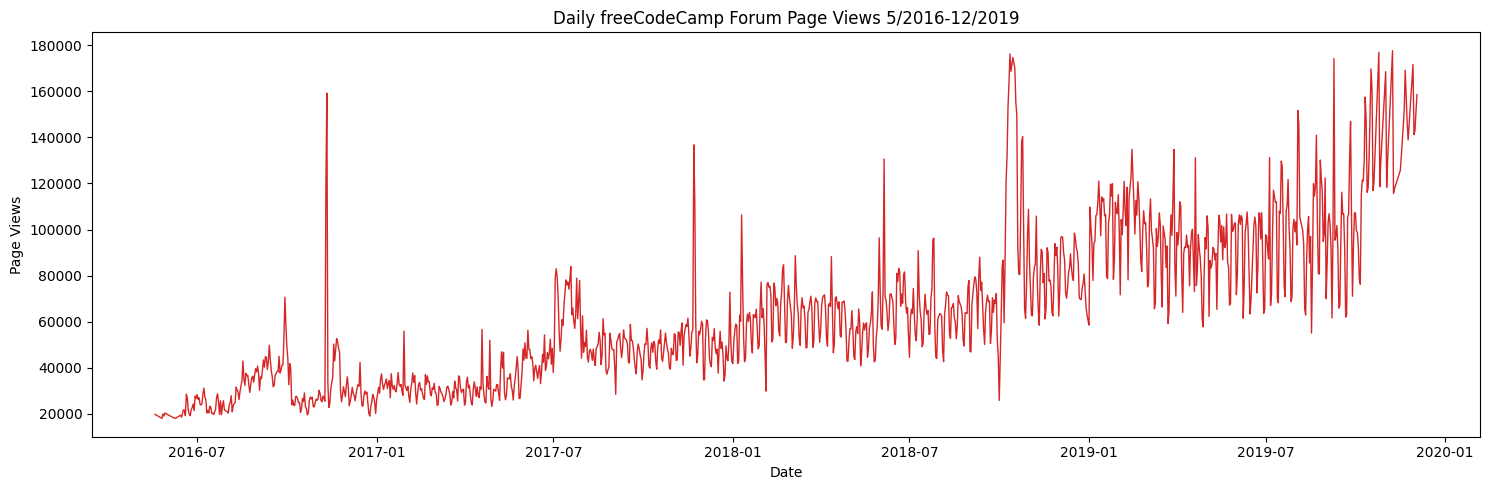

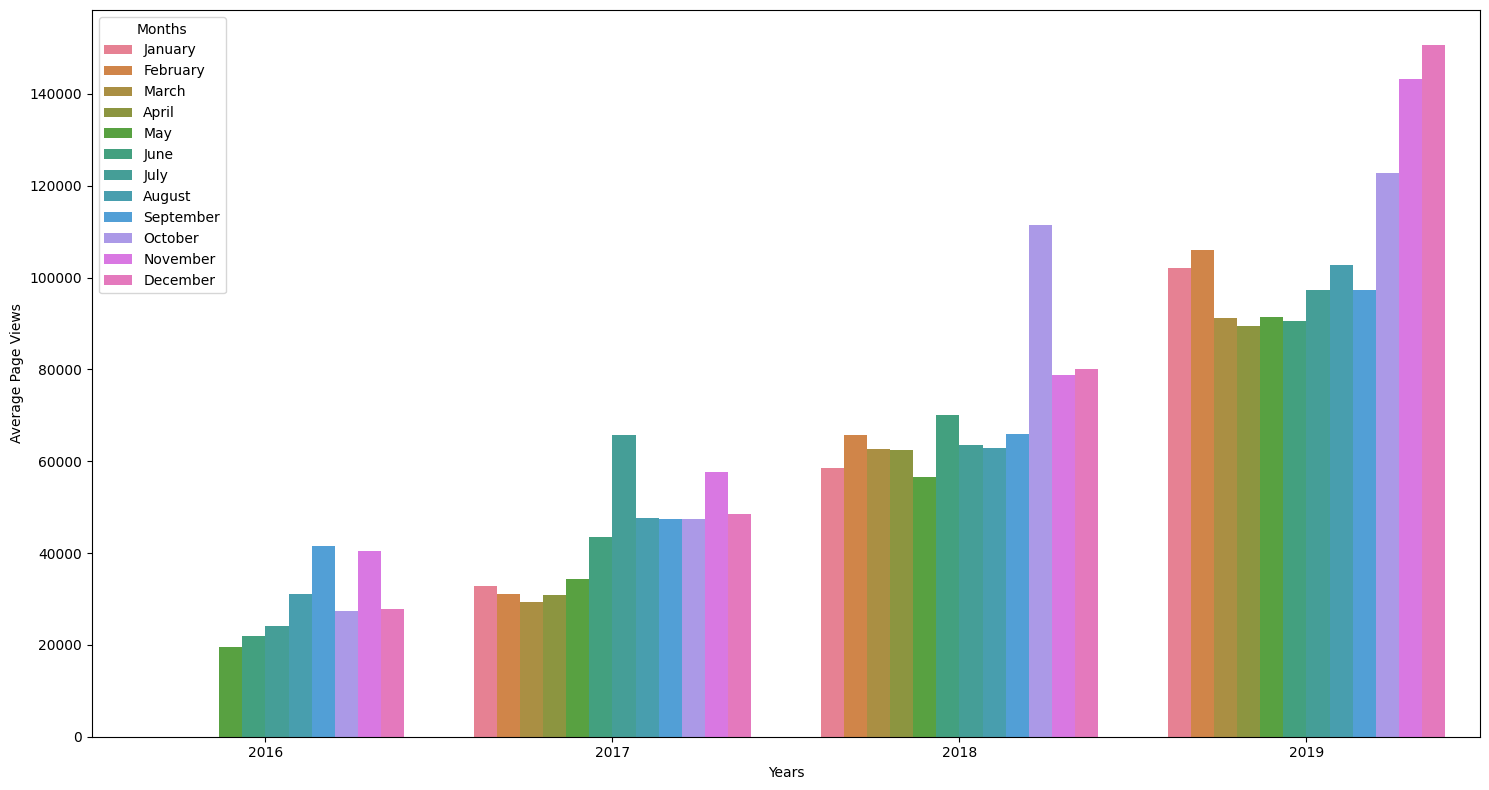

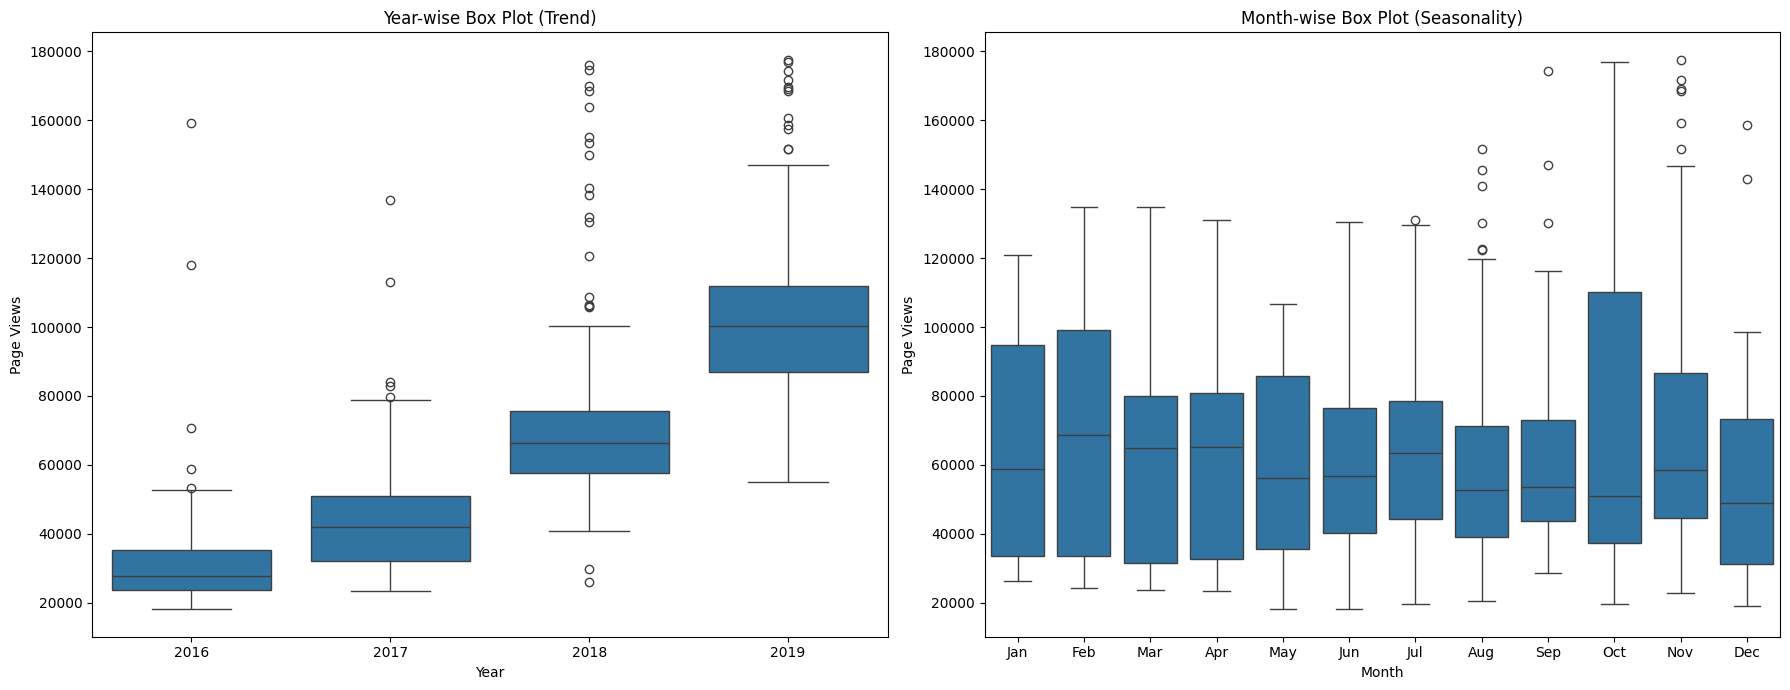

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

# ------------------------------------------------------------------
# Load and clean the dataset
# ------------------------------------------------------------------

df = pd.read_csv(
    "fcc-forum-pageviews.csv",
    parse_dates=["date"],
    index_col="date"
)

# Remove the top and bottom 2.5% of page views
df = df[
    (df["value"] >= df["value"].quantile(0.025))
    & (df["value"] <= df["value"].quantile(0.975))
]


# ------------------------------------------------------------------
# Line Plot
# ------------------------------------------------------------------

def draw_line_plot():
    """
    Draw a line plot showing daily freeCodeCamp forum page views.
    """

    fig, ax = plt.subplots(figsize=(15, 5))

    ax.plot(df.index, df["value"], color="tab:red", linewidth=1)

    ax.set_title("Daily freeCodeCamp Forum Page Views 5/2016-12/2019")
    ax.set_xlabel("Date")
    ax.set_ylabel("Page Views")

    fig.tight_layout()

    # Do not modify the next two lines
    fig.savefig("line_plot.png")
    return fig


# ------------------------------------------------------------------
# Bar Plot
# ------------------------------------------------------------------

def draw_bar_plot():
    """
    Draw a bar plot showing average monthly page views grouped by year.
    """

    df_bar = df.copy()

    df_bar["year"] = df_bar.index.year
    df_bar["month"] = df_bar.index.month_name()

    df_bar = (
        df_bar.groupby(["year", "month"])["value"]
        .mean()
        .reset_index()
    )

    month_order = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ]

    fig, ax = plt.subplots(figsize=(15, 8))

    sns.barplot(
        data=df_bar,
        x="year",
        y="value",
        hue="month",
        hue_order=month_order,
        ax=ax,
    )

    ax.set_xlabel("Years")
    ax.set_ylabel("Average Page Views")
    ax.legend(title="Months")

    fig.tight_layout()

    # Do not modify the next two lines
    fig.savefig("bar_plot.png")
    return fig


# ------------------------------------------------------------------
# Box Plot
# ------------------------------------------------------------------

def draw_box_plot():
    """
    Draw year-wise and month-wise box plots for trend and seasonality.
    """

    df_box = df.copy().reset_index()

    df_box["year"] = df_box["date"].dt.year
    df_box["month"] = df_box["date"].dt.strftime("%b")

    month_order = [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Year-wise box plot
    sns.boxplot(
        data=df_box,
        x="year",
        y="value",
        ax=axes[0]
    )

    axes[0].set_title("Year-wise Box Plot (Trend)")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Page Views")

    # Month-wise box plot
    sns.boxplot(
        data=df_box,
        x="month",
        y="value",
        order=month_order,
        ax=axes[1]
    )

    axes[1].set_title("Month-wise Box Plot (Seasonality)")
    axes[1].set_xlabel("Month")
    axes[1].set_ylabel("Page Views")

    fig.tight_layout()

    # Do not modify the next two lines
    fig.savefig("box_plot.png")
    return fig


# ------------------------------------------------------------------
# Run directly (optional)
# ------------------------------------------------------------------

if __name__ == "__main__":
    draw_line_plot()
    draw_bar_plot()
    draw_box_plot()
    plt.show()